In [2]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


### Seasonal Soil Moisture

In [3]:
#Figure 3.4


AGGREGATE SPRING AND SUMMER CHANGES

Soil moisture group: smap_raw
2030s | spring: hist=375.12 mm, proj=396.78 mm, change=+5.77%
2030s | summer: hist=307.47 mm, proj=324.04 mm, change=+5.39%
2060s | spring: hist=375.12 mm, proj=394.68 mm, change=+5.21%
2060s | summer: hist=307.47 mm, proj=314.64 mm, change=+2.33%
2090s | spring: hist=375.12 mm, proj=392.27 mm, change=+4.57%
2090s | summer: hist=307.47 mm, proj=303.08 mm, change=-1.43%

Soil moisture group: insitu7
2030s | spring: hist=410.13 mm, proj=414.05 mm, change=+0.96%
2030s | summer: hist=360.41 mm, proj=344.31 mm, change=-4.47%
2060s | spring: hist=410.13 mm, proj=411.79 mm, change=+0.40%
2060s | summer: hist=360.41 mm, proj=335.16 mm, change=-7.01%
2090s | spring: hist=410.13 mm, proj=409.17 mm, change=-0.23%
2090s | summer: hist=360.41 mm, proj=323.82 mm, change=-10.15%

Precipitation: historical = GRIDMET, projection = LOCA2
2030s | spring: hist=114.37 mm, proj=99.98 mm, change=-12.59%
2030s | summer: hist=117.65 mm, proj=9

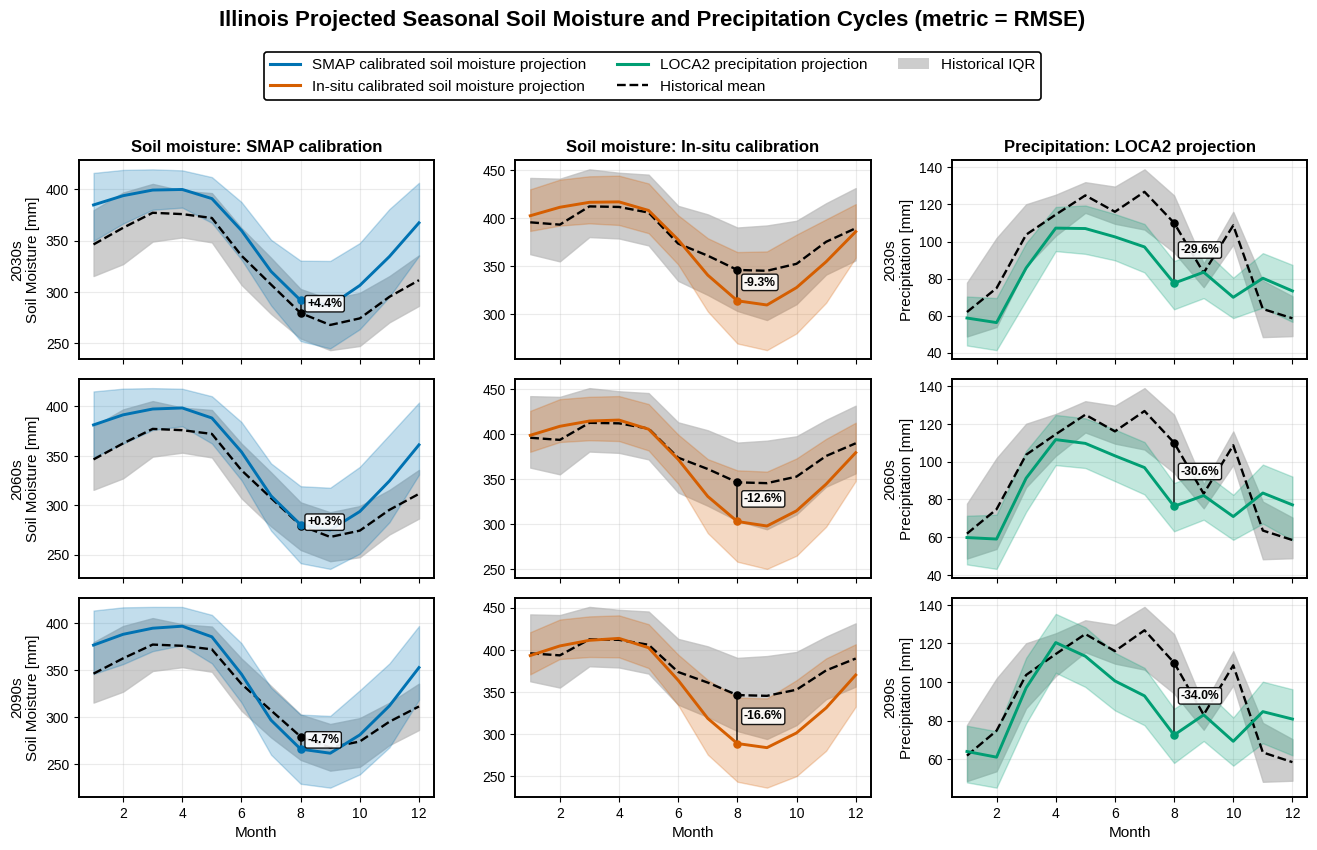

In [5]:

# ============================================================
# GLOBAL FONT SETTINGS
# ============================================================
mpl.rcParams.update({
    "font.family": "Liberation Sans",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "figure.titlesize": 16,

    # Optional for publication figures
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# ============================================================
# PATHS
# ============================================================
METRIC = "rmse"

SM_MONTHLY_NC = (
    "/data/keeling/a/tahsina2/Alam_et_al_2026/data/"
    "processed_projection_stats_monthly_cycle_all17_smapraw_insitu7/"
    f"soil_moisture_monthly_cycle_smapraw_insitu7_all17_{METRIC}.nc"
)

PRECIP_MONTHLY_NC = (
    "/data/keeling/a/tahsina2/Alam_et_al_2026/data/"
    "processed_projection_stats_precip_loca2_zarr/"
    f"precip_monthly_totals_with_historical_{METRIC}_gridmet.nc"
)

PLOT_DIR = "/data/keeling/a/tahsina2/Alam_et_al_2026/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

OUT_PNG = os.path.join(
    PLOT_DIR,
    f"Fig34_merged_soil_moisture_precip_cycle_summer_pct_smapraw_insitu7_{METRIC}_gridmet_hist.png"
)

# ============================================================
# SETTINGS
# ============================================================
PERIODS = ["2030s", "2060s", "2090s"]
MONTHS = np.arange(1, 13)

# Only annotate summer representative month
SUMMER_TARGET_MONTH = 8

SEASON_MONTHS = {
    "spring": [3, 4, 5],
    "summer": [6, 7, 8],
}

SM_GROUPS = ["smap_raw", "insitu7"]

GROUP_TITLES = {
    "smap_raw": "Soil moisture: SMAP calibration",
    "insitu7": "Soil moisture: In-situ calibration",
}

GROUP_COLORS = {
    "smap_raw": "#0072B2",
    "insitu7": "#D55E00",
}

PRECIP_GROUP = "insitu7"
PRECIP_HIST_GROUP = "gridmet"
PRECIP_COLOR = "#009E73"

HIST_MEAN_COLOR = "black"
HIST_FILL_COLOR = "#BDBDBD"

ROW_LABELS_SM = {
    "2030s": "2030s\nSoil Moisture [mm]",
    "2060s": "2060s\nSoil Moisture [mm]",
    "2090s": "2090s\nSoil Moisture [mm]",
}

ROW_LABELS_PR = {
    "2030s": "2030s\nPrecipitation [mm]",
    "2060s": "2060s\nPrecipitation [mm]",
    "2090s": "2090s\nPrecipitation [mm]",
}

# ============================================================
# HELPERS
# ============================================================
def open_nc_safe(path):
    last_err = None
    for eng in ["netcdf4", "h5netcdf", "scipy"]:
        try:
            ds = xr.open_dataset(path, engine=eng)
            _ = ds.dims
            return ds
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Could not open {path}. Last error: {last_err}")


def pick_dataarray(ds, names):
    for name in names:
        if name in ds.data_vars:
            return ds[name], name
    raise KeyError(f"None found from {names}. Available: {list(ds.data_vars)}")


def compute_percent_change(hist_val, proj_val):
    if not np.isfinite(hist_val) or hist_val == 0:
        return np.nan
    return 100.0 * (proj_val - hist_val) / hist_val


def extract_series(ds, var_name, source, period, group=None, metric=None):
    da = ds[var_name]
    sel = {}

    if "source" in da.dims:
        sel["source"] = source
    if "period" in da.dims:
        sel["period"] = period
    if group is not None and "group" in da.dims:
        sel["group"] = group
    if metric is not None and "metric" in da.dims:
        sel["metric"] = metric

    return np.asarray(da.sel(**sel).values, dtype=float)


def seasonal_mean(series, season):
    idx = [m - 1 for m in SEASON_MONTHS[season]]
    return float(np.nanmean(series[idx]))


def add_month_annotation(ax, month, hist_val, proj_val, color, label_text, y_offset=0):
    y_low = min(hist_val, proj_val)
    y_high = max(hist_val, proj_val)
    y_mid = 0.5 * (y_low + y_high) + y_offset

    ax.scatter([month], [hist_val], color=HIST_MEAN_COLOR, s=26, zorder=7)
    ax.scatter([month], [proj_val], color=color, s=26, zorder=7)

    ax.plot(
        [month, month],
        [hist_val, proj_val],
        color="black",
        linewidth=1.1,
        alpha=0.9,
        zorder=6
    )

    ax.text(
        month + 0.22,
        y_mid,
        label_text,
        fontsize=8.8,
        fontweight="bold",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="black",
            alpha=0.9
        ),
        zorder=8
    )


def print_aggregate_changes(ds_sm, ds_pr, sm_mean_name, pr_mean_name):
    print("\n" + "=" * 80)
    print("AGGREGATE SPRING AND SUMMER CHANGES")
    print("=" * 80)

    for group in SM_GROUPS:
        print(f"\nSoil moisture group: {group}")

        hist_sm = extract_series(
            ds_sm,
            sm_mean_name,
            source="historical",
            period="historical",
            group=group,
            metric=METRIC
        )

        for period in PERIODS:
            proj_sm = extract_series(
                ds_sm,
                sm_mean_name,
                source="projection",
                period=period,
                group=group,
                metric=METRIC
            )

            for season in ["spring", "summer"]:
                hist_val = seasonal_mean(hist_sm, season)
                proj_val = seasonal_mean(proj_sm, season)
                pct = compute_percent_change(hist_val, proj_val)

                print(
                    f"{period} | {season}: "
                    f"hist={hist_val:.2f} mm, proj={proj_val:.2f} mm, change={pct:+.2f}%"
                )

    print("\nPrecipitation: historical = GRIDMET, projection = LOCA2")

    hist_pr = extract_series(
        ds_pr,
        pr_mean_name,
        source="historical",
        period="historical",
        group=PRECIP_HIST_GROUP
    )

    for period in PERIODS:
        proj_pr = extract_series(
            ds_pr,
            pr_mean_name,
            source="projection",
            period=period,
            group=PRECIP_GROUP
        )

        for season in ["spring", "summer"]:
            hist_val = seasonal_mean(hist_pr, season)
            proj_val = seasonal_mean(proj_pr, season)
            pct = compute_percent_change(hist_val, proj_val)

            print(
                f"{period} | {season}: "
                f"hist={hist_val:.2f} mm, proj={proj_val:.2f} mm, change={pct:+.2f}%"
            )


# ============================================================
# PLOT
# ============================================================
def plot_merged_cycle(sm_nc, precip_nc, save_png=None):
    ds_sm = open_nc_safe(sm_nc)
    ds_pr = open_nc_safe(precip_nc)

    sm_mean_da, sm_mean_name = pick_dataarray(ds_sm, ["mean"])
    sm_q25_da, sm_q25_name = pick_dataarray(ds_sm, ["q25"])
    sm_q75_da, sm_q75_name = pick_dataarray(ds_sm, ["q75"])

    pr_mean_da, pr_mean_name = pick_dataarray(ds_pr, ["mean", "precip_mean", "pr_mean"])
    pr_q25_da, pr_q25_name = pick_dataarray(ds_pr, ["q25", "precip_q25", "pr_q25"])
    pr_q75_da, pr_q75_name = pick_dataarray(ds_pr, ["q75", "precip_q75", "pr_q75"])

    print_aggregate_changes(ds_sm, ds_pr, sm_mean_name, pr_mean_name)

    fig, axes = plt.subplots(
        nrows=3,
        ncols=3,
        figsize=(13.5, 8.6),
        sharex=True,
        sharey=False
    )

    # --------------------------------------------------------
    # Soil moisture columns
    # --------------------------------------------------------
    for col, group in enumerate(SM_GROUPS):
        color = GROUP_COLORS[group]

        for row, period in enumerate(PERIODS):
            ax = axes[row, col]

            hist_mean = extract_series(
                ds_sm, sm_mean_name,
                source="historical",
                period="historical",
                group=group,
                metric=METRIC
            )
            hist_q25 = extract_series(
                ds_sm, sm_q25_name,
                source="historical",
                period="historical",
                group=group,
                metric=METRIC
            )
            hist_q75 = extract_series(
                ds_sm, sm_q75_name,
                source="historical",
                period="historical",
                group=group,
                metric=METRIC
            )

            proj_mean = extract_series(
                ds_sm, sm_mean_name,
                source="projection",
                period=period,
                group=group,
                metric=METRIC
            )
            proj_q25 = extract_series(
                ds_sm, sm_q25_name,
                source="projection",
                period=period,
                group=group,
                metric=METRIC
            )
            proj_q75 = extract_series(
                ds_sm, sm_q75_name,
                source="projection",
                period=period,
                group=group,
                metric=METRIC
            )

            ax.fill_between(MONTHS, hist_q25, hist_q75, color=HIST_FILL_COLOR, alpha=0.75, zorder=1)
            ax.fill_between(MONTHS, proj_q25, proj_q75, color=color, alpha=0.24, zorder=2)

            ax.plot(MONTHS, hist_mean, linestyle="--", color=HIST_MEAN_COLOR, linewidth=1.7, zorder=4)
            ax.plot(MONTHS, proj_mean, linestyle="-", color=color, linewidth=2.1, zorder=5)

            # Summer-only percent annotation
            idx = SUMMER_TARGET_MONTH - 1
            hist_val = float(hist_mean[idx])
            proj_val = float(proj_mean[idx])
            pct = compute_percent_change(hist_val, proj_val)

            add_month_annotation(
                ax=ax,
                month=SUMMER_TARGET_MONTH,
                hist_val=hist_val,
                proj_val=proj_val,
                color=color,
                label_text=f"{pct:+.1f}%",
                y_offset=0
            )

            if row == 0:
                ax.set_title(GROUP_TITLES[group], fontsize=12, fontweight="bold")

            if col == 0:
                ax.set_ylabel(ROW_LABELS_SM[period], fontsize=11)

            ax.set_xlim(0.5, 12.5)
            ax.set_xticks([2, 4, 6, 8, 10, 12])
            ax.grid(True, alpha=0.25, linewidth=0.8)

            for spine in ax.spines.values():
                spine.set_linewidth(1.4)

    # --------------------------------------------------------
    # Precipitation column
    # --------------------------------------------------------
    col = 2

    for row, period in enumerate(PERIODS):
        ax = axes[row, col]

        hist_mean = extract_series(
            ds_pr,
            pr_mean_name,
            source="historical",
            period="historical",
            group=PRECIP_HIST_GROUP
        )
        hist_q25 = extract_series(
            ds_pr,
            pr_q25_name,
            source="historical",
            period="historical",
            group=PRECIP_HIST_GROUP
        )
        hist_q75 = extract_series(
            ds_pr,
            pr_q75_name,
            source="historical",
            period="historical",
            group=PRECIP_HIST_GROUP
        )

        proj_mean = extract_series(
            ds_pr,
            pr_mean_name,
            source="projection",
            period=period,
            group=PRECIP_GROUP
        )
        proj_q25 = extract_series(
            ds_pr,
            pr_q25_name,
            source="projection",
            period=period,
            group=PRECIP_GROUP
        )
        proj_q75 = extract_series(
            ds_pr,
            pr_q75_name,
            source="projection",
            period=period,
            group=PRECIP_GROUP
        )

        ax.fill_between(MONTHS, hist_q25, hist_q75, color=HIST_FILL_COLOR, alpha=0.75, zorder=1)
        ax.fill_between(MONTHS, proj_q25, proj_q75, color=PRECIP_COLOR, alpha=0.24, zorder=2)

        ax.plot(MONTHS, hist_mean, linestyle="--", color=HIST_MEAN_COLOR, linewidth=1.7, zorder=4)
        ax.plot(MONTHS, proj_mean, linestyle="-", color=PRECIP_COLOR, linewidth=2.1, zorder=5)

        # Summer-only percent annotation
        idx = SUMMER_TARGET_MONTH - 1
        hist_val = float(hist_mean[idx])
        proj_val = float(proj_mean[idx])
        pct = compute_percent_change(hist_val, proj_val)

        add_month_annotation(
            ax=ax,
            month=SUMMER_TARGET_MONTH,
            hist_val=hist_val,
            proj_val=proj_val,
            color=PRECIP_COLOR,
            label_text=f"{pct:+.1f}%",
            y_offset=0
        )

        if row == 0:
            ax.set_title("Precipitation: LOCA2 projection", fontsize=12, fontweight="bold")

        ax.set_ylabel(ROW_LABELS_PR[period], fontsize=11)

        ax.set_xlim(0.5, 12.5)
        ax.set_xticks([2, 4, 6, 8, 10, 12])
        ax.grid(True, alpha=0.25, linewidth=0.8)

        for spine in ax.spines.values():
            spine.set_linewidth(1.4)

    for ax in axes[-1, :]:
        ax.set_xlabel("Month")

    legend_handles = [
        Line2D([0], [0], color=GROUP_COLORS["smap_raw"], lw=2.2, label="SMAP calibrated soil moisture projection"),
        Line2D([0], [0], color=GROUP_COLORS["insitu7"], lw=2.2, label="In-situ calibrated soil moisture projection"),
        Line2D([0], [0], color=PRECIP_COLOR, lw=2.2, label="LOCA2 precipitation projection"),
        Line2D([0], [0], color=HIST_MEAN_COLOR, lw=1.7, linestyle="--", label="Historical mean"),
        Patch(facecolor=HIST_FILL_COLOR, alpha=0.75, label="Historical IQR"),
    ]

    legend = fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=3,
        frameon=True,
        fontsize=11
    )

    frame = legend.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("black")
    frame.set_linewidth(1.2)
    frame.set_alpha(1.0)

    fig.suptitle(
        f"Illinois Projected Seasonal Soil Moisture and Precipitation Cycles (metric = {METRIC.upper()})",
        fontsize=16,
        fontweight="bold",
        y=0.995
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        bottom=0.08,
        top=0.82,
        wspace=0.23,
        hspace=0.10
    )

    if save_png is not None:
        fig.savefig(
            save_png,
            dpi=1200,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none"
        )
        print("Saved:", save_png)

    plt.show()
    plt.close(fig)

    ds_sm.close()
    ds_pr.close()


plot_merged_cycle(
    SM_MONTHLY_NC,
    PRECIP_MONTHLY_NC,
    save_png=OUT_PNG
)


AGGREGATE SPRING AND SUMMER CHANGES: FIG A.3

Soil moisture group: Noah
2030s | spring: hist=309.48 mm, proj=318.59 mm, change=+2.94%
2030s | summer: hist=265.15 mm, proj=250.49 mm, change=-5.53%
2060s | spring: hist=309.48 mm, proj=316.61 mm, change=+2.30%
2060s | summer: hist=265.15 mm, proj=241.90 mm, change=-8.77%
2090s | spring: hist=309.48 mm, proj=314.42 mm, change=+1.59%
2090s | summer: hist=265.15 mm, proj=231.44 mm, change=-12.71%

Soil moisture group: VIC
2030s | spring: hist=356.61 mm, proj=372.32 mm, change=+4.40%
2030s | summer: hist=296.50 mm, proj=299.11 mm, change=+0.88%
2060s | spring: hist=356.61 mm, proj=370.32 mm, change=+3.84%
2060s | summer: hist=296.50 mm, proj=289.01 mm, change=-2.53%
2090s | spring: hist=356.61 mm, proj=367.93 mm, change=+3.17%
2090s | summer: hist=296.50 mm, proj=276.55 mm, change=-6.73%

Soil moisture group: Mosaic
2030s | spring: hist=339.08 mm, proj=379.78 mm, change=+12.00%
2030s | summer: hist=290.97 mm, proj=298.14 mm, change=+2.46%
20

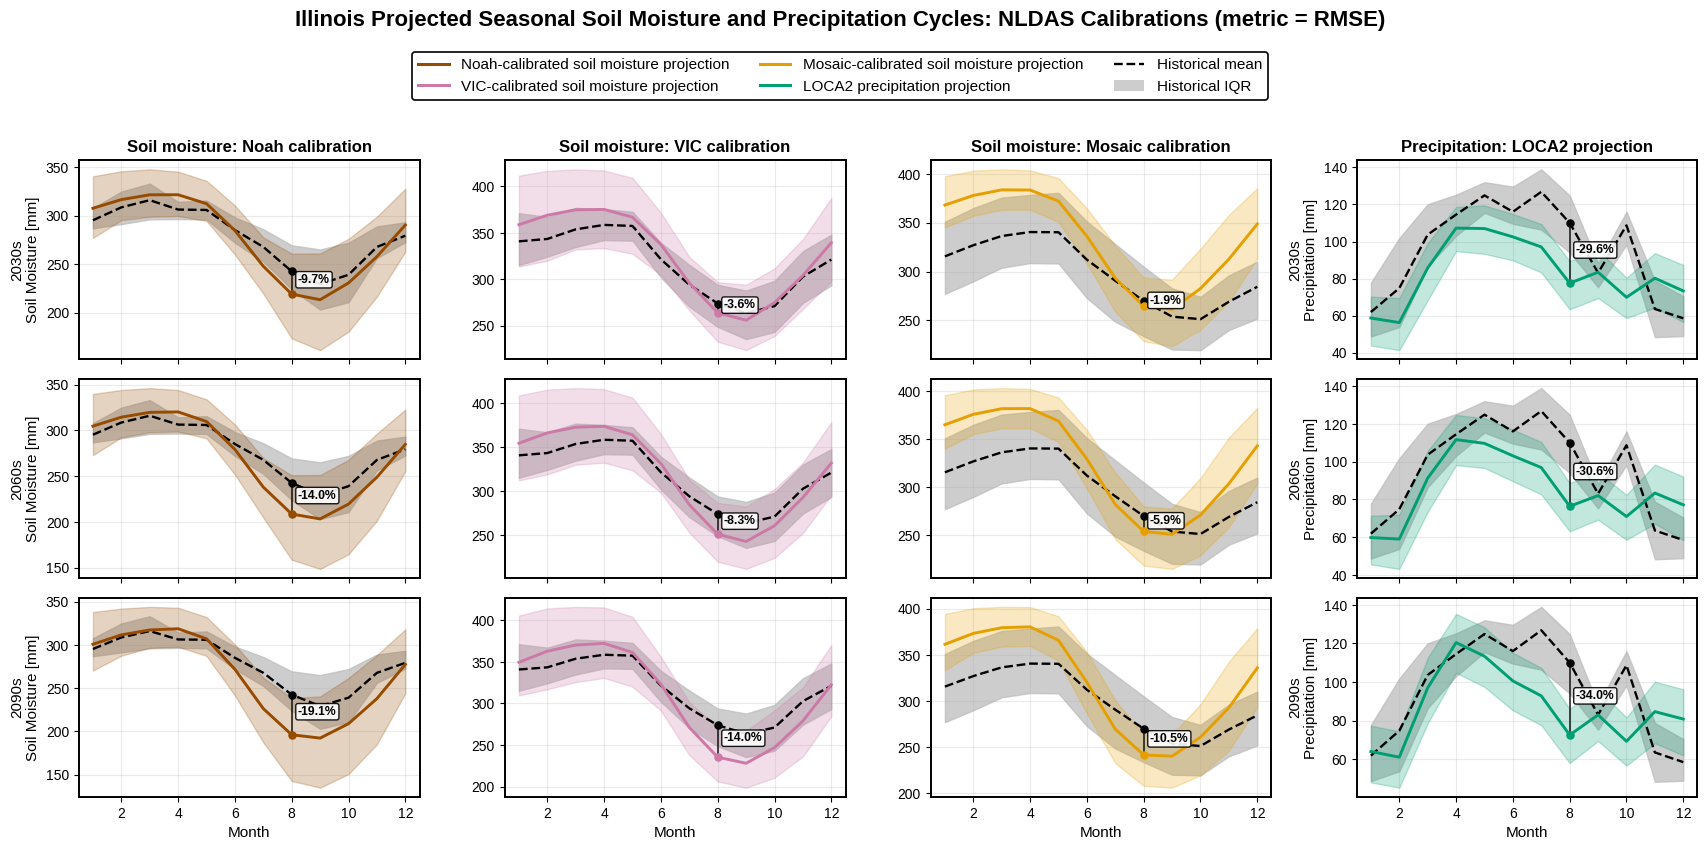

In [8]:
# ============================================================
# FIG A.3: NLDAS CALIBRATIONS + PRECIPITATION
# Assumes Fig 3.4 cell has already been run.
# Keeps internal group names but removes "raw" from all output text.
# ============================================================

SM_MONTHLY_NC_A3 = (
    "/data/keeling/a/tahsina2/Alam_et_al_2026/data/"
    "processed_projection_stats_monthly_cycle_all17_all_raw/"
    f"soil_moisture_monthly_cycle_all_raw_all17_{METRIC}.nc"
)

OUT_PNG_A3 = os.path.join(
    PLOT_DIR,
    f"FigA3_merged_soil_moisture_precip_cycle_summer_pct_nldas_{METRIC}_gridmet_hist.png"
)

SM_GROUPS_A3 = ["noah_raw", "vic_raw", "mosaic_raw"]

GROUP_TITLES_A3 = {
    "noah_raw": "Soil moisture: Noah calibration",
    "vic_raw": "Soil moisture: VIC calibration",
    "mosaic_raw": "Soil moisture: Mosaic calibration",
}

GROUP_LABELS_A3 = {
    "noah_raw": "Noah",
    "vic_raw": "VIC",
    "mosaic_raw": "Mosaic",
}

GROUP_COLORS_A3 = {
    "noah_raw": "#964B00",
    "vic_raw": "#CC79A7",
    "mosaic_raw": "#E69F00",
}


def print_aggregate_changes_A3(ds_sm, ds_pr, sm_mean_name, pr_mean_name):
    print("\n" + "=" * 80)
    print("AGGREGATE SPRING AND SUMMER CHANGES: FIG A.3")
    print("=" * 80)

    for group in SM_GROUPS_A3:
        print(f"\nSoil moisture group: {GROUP_LABELS_A3[group]}")

        hist_sm = extract_series(
            ds_sm,
            sm_mean_name,
            source="historical",
            period="historical",
            group=group,
            metric=METRIC
        )

        for period in PERIODS:
            proj_sm = extract_series(
                ds_sm,
                sm_mean_name,
                source="projection",
                period=period,
                group=group,
                metric=METRIC
            )

            for season in ["spring", "summer"]:
                hist_val = seasonal_mean(hist_sm, season)
                proj_val = seasonal_mean(proj_sm, season)
                pct = compute_percent_change(hist_val, proj_val)

                print(
                    f"{period} | {season}: "
                    f"hist={hist_val:.2f} mm, proj={proj_val:.2f} mm, change={pct:+.2f}%"
                )

    print("\nPrecipitation: historical = GRIDMET, projection = LOCA2")

    hist_pr = extract_series(
        ds_pr,
        pr_mean_name,
        source="historical",
        period="historical",
        group=PRECIP_HIST_GROUP
    )

    for period in PERIODS:
        proj_pr = extract_series(
            ds_pr,
            pr_mean_name,
            source="projection",
            period=period,
            group=PRECIP_GROUP
        )

        for season in ["spring", "summer"]:
            hist_val = seasonal_mean(hist_pr, season)
            proj_val = seasonal_mean(proj_pr, season)
            pct = compute_percent_change(hist_val, proj_val)

            print(
                f"{period} | {season}: "
                f"hist={hist_val:.2f} mm, proj={proj_val:.2f} mm, change={pct:+.2f}%"
            )


def plot_merged_cycle_A3(sm_nc, precip_nc, save_png=None):
    ds_sm = open_nc_safe(sm_nc)
    ds_pr = open_nc_safe(precip_nc)

    sm_mean_da, sm_mean_name = pick_dataarray(ds_sm, ["mean"])
    sm_q25_da, sm_q25_name = pick_dataarray(ds_sm, ["q25"])
    sm_q75_da, sm_q75_name = pick_dataarray(ds_sm, ["q75"])

    pr_mean_da, pr_mean_name = pick_dataarray(ds_pr, ["mean", "precip_mean", "pr_mean"])
    pr_q25_da, pr_q25_name = pick_dataarray(ds_pr, ["q25", "precip_q25", "pr_q25"])
    pr_q75_da, pr_q75_name = pick_dataarray(ds_pr, ["q75", "precip_q75", "pr_q75"])

    print_aggregate_changes_A3(ds_sm, ds_pr, sm_mean_name, pr_mean_name)

    fig, axes = plt.subplots(
        nrows=3,
        ncols=4,
        figsize=(17.5, 8.6),
        sharex=True,
        sharey=False
    )

    # --------------------------------------------------------
    # Soil moisture columns: Noah, VIC, Mosaic
    # --------------------------------------------------------
    for col, group in enumerate(SM_GROUPS_A3):
        color = GROUP_COLORS_A3[group]

        for row, period in enumerate(PERIODS):
            ax = axes[row, col]

            hist_mean = extract_series(
                ds_sm,
                sm_mean_name,
                source="historical",
                period="historical",
                group=group,
                metric=METRIC
            )
            hist_q25 = extract_series(
                ds_sm,
                sm_q25_name,
                source="historical",
                period="historical",
                group=group,
                metric=METRIC
            )
            hist_q75 = extract_series(
                ds_sm,
                sm_q75_name,
                source="historical",
                period="historical",
                group=group,
                metric=METRIC
            )

            proj_mean = extract_series(
                ds_sm,
                sm_mean_name,
                source="projection",
                period=period,
                group=group,
                metric=METRIC
            )
            proj_q25 = extract_series(
                ds_sm,
                sm_q25_name,
                source="projection",
                period=period,
                group=group,
                metric=METRIC
            )
            proj_q75 = extract_series(
                ds_sm,
                sm_q75_name,
                source="projection",
                period=period,
                group=group,
                metric=METRIC
            )

            ax.fill_between(
                MONTHS,
                hist_q25,
                hist_q75,
                color=HIST_FILL_COLOR,
                alpha=0.75,
                zorder=1
            )

            ax.fill_between(
                MONTHS,
                proj_q25,
                proj_q75,
                color=color,
                alpha=0.24,
                zorder=2
            )

            ax.plot(
                MONTHS,
                hist_mean,
                linestyle="--",
                color=HIST_MEAN_COLOR,
                linewidth=1.7,
                zorder=4
            )

            ax.plot(
                MONTHS,
                proj_mean,
                linestyle="-",
                color=color,
                linewidth=2.1,
                zorder=5
            )

            idx = SUMMER_TARGET_MONTH - 1
            hist_val = float(hist_mean[idx])
            proj_val = float(proj_mean[idx])
            pct = compute_percent_change(hist_val, proj_val)

            add_month_annotation(
                ax=ax,
                month=SUMMER_TARGET_MONTH,
                hist_val=hist_val,
                proj_val=proj_val,
                color=color,
                label_text=f"{pct:+.1f}%",
                y_offset=0
            )

            if row == 0:
                ax.set_title(
                    GROUP_TITLES_A3[group],
                    fontsize=12,
                    fontweight="bold"
                )

            if col == 0:
                ax.set_ylabel(ROW_LABELS_SM[period], fontsize=11)

            ax.set_xlim(0.5, 12.5)
            ax.set_xticks([2, 4, 6, 8, 10, 12])
            ax.grid(True, alpha=0.25, linewidth=0.8)

            for spine in ax.spines.values():
                spine.set_linewidth(1.4)

    # --------------------------------------------------------
    # Precipitation column
    # --------------------------------------------------------
    col = 3

    for row, period in enumerate(PERIODS):
        ax = axes[row, col]

        hist_mean = extract_series(
            ds_pr,
            pr_mean_name,
            source="historical",
            period="historical",
            group=PRECIP_HIST_GROUP
        )
        hist_q25 = extract_series(
            ds_pr,
            pr_q25_name,
            source="historical",
            period="historical",
            group=PRECIP_HIST_GROUP
        )
        hist_q75 = extract_series(
            ds_pr,
            pr_q75_name,
            source="historical",
            period="historical",
            group=PRECIP_HIST_GROUP
        )

        proj_mean = extract_series(
            ds_pr,
            pr_mean_name,
            source="projection",
            period=period,
            group=PRECIP_GROUP
        )
        proj_q25 = extract_series(
            ds_pr,
            pr_q25_name,
            source="projection",
            period=period,
            group=PRECIP_GROUP
        )
        proj_q75 = extract_series(
            ds_pr,
            pr_q75_name,
            source="projection",
            period=period,
            group=PRECIP_GROUP
        )

        ax.fill_between(
            MONTHS,
            hist_q25,
            hist_q75,
            color=HIST_FILL_COLOR,
            alpha=0.75,
            zorder=1
        )

        ax.fill_between(
            MONTHS,
            proj_q25,
            proj_q75,
            color=PRECIP_COLOR,
            alpha=0.24,
            zorder=2
        )

        ax.plot(
            MONTHS,
            hist_mean,
            linestyle="--",
            color=HIST_MEAN_COLOR,
            linewidth=1.7,
            zorder=4
        )

        ax.plot(
            MONTHS,
            proj_mean,
            linestyle="-",
            color=PRECIP_COLOR,
            linewidth=2.1,
            zorder=5
        )

        idx = SUMMER_TARGET_MONTH - 1
        hist_val = float(hist_mean[idx])
        proj_val = float(proj_mean[idx])
        pct = compute_percent_change(hist_val, proj_val)

        add_month_annotation(
            ax=ax,
            month=SUMMER_TARGET_MONTH,
            hist_val=hist_val,
            proj_val=proj_val,
            color=PRECIP_COLOR,
            label_text=f"{pct:+.1f}%",
            y_offset=0
        )

        if row == 0:
            ax.set_title(
                "Precipitation: LOCA2 projection",
                fontsize=12,
                fontweight="bold"
            )

        ax.set_ylabel(ROW_LABELS_PR[period], fontsize=11)

        ax.set_xlim(0.5, 12.5)
        ax.set_xticks([2, 4, 6, 8, 10, 12])
        ax.grid(True, alpha=0.25, linewidth=0.8)

        for spine in ax.spines.values():
            spine.set_linewidth(1.4)

    for ax in axes[-1, :]:
        ax.set_xlabel("Month")

    legend_handles = [
        Line2D(
            [0], [0],
            color=GROUP_COLORS_A3["noah_raw"],
            lw=2.2,
            label="Noah-calibrated soil moisture projection"
        ),
        Line2D(
            [0], [0],
            color=GROUP_COLORS_A3["vic_raw"],
            lw=2.2,
            label="VIC-calibrated soil moisture projection"
        ),
        Line2D(
            [0], [0],
            color=GROUP_COLORS_A3["mosaic_raw"],
            lw=2.2,
            label="Mosaic-calibrated soil moisture projection"
        ),
        Line2D(
            [0], [0],
            color=PRECIP_COLOR,
            lw=2.2,
            label="LOCA2 precipitation projection"
        ),
        Line2D(
            [0], [0],
            color=HIST_MEAN_COLOR,
            lw=1.7,
            linestyle="--",
            label="Historical mean"
        ),
        Patch(
            facecolor=HIST_FILL_COLOR,
            alpha=0.75,
            label="Historical IQR"
        ),
    ]

    legend = fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=3,
        frameon=True,
        fontsize=11
    )

    frame = legend.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("black")
    frame.set_linewidth(1.2)
    frame.set_alpha(1.0)

    fig.suptitle(
        f"Illinois Projected Seasonal Soil Moisture and Precipitation Cycles: NLDAS Calibrations (metric = {METRIC.upper()})",
        fontsize=16,
        fontweight="bold",
        y=0.995
    )

    fig.subplots_adjust(
        left=0.065,
        right=0.990,
        bottom=0.08,
        top=0.82,
        wspace=0.25,
        hspace=0.10
    )

    if save_png is not None:
        fig.savefig(
            save_png,
            dpi=1200,
            bbox_inches="tight",
            facecolor="white",
            edgecolor="none"
        )
        print("Saved:", save_png)

    plt.show()
    plt.close(fig)

    ds_sm.close()
    ds_pr.close()


plot_merged_cycle_A3(
    SM_MONTHLY_NC_A3,
    PRECIP_MONTHLY_NC,
    save_png=OUT_PNG_A3
)